In [1]:
from tensorflow.keras import layers
from tensorflow.keras import models


model = models.Sequential([
    layers.Input(shape=(150, 150, 3)),

    layers.Conv2D(32, (3, 3), activation="relu"),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(64, (3, 3), activation="relu"),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(128, (3, 3), activation="relu"),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(128, (3, 3), activation="relu"),
    layers.MaxPooling2D((2, 2)),

    layers.Flatten(),
    layers.Dropout(0.5),
    layers.Dense(512, activation="relu"),

    layers.Dense(1, activation="sigmoid")
])

model.compile(
    loss="binary_crossentropy",
    optimizer="rmsprop",
    metrics=["accuracy"]
)


In [3]:
model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d (Conv2D)             (None, 148, 148, 32)      896       
                                                                 
 max_pooling2d (MaxPooling2  (None, 74, 74, 32)        0         
 D)                                                              
                                                                 
 conv2d_1 (Conv2D)           (None, 72, 72, 64)        18496     
                                                                 
 max_pooling2d_1 (MaxPoolin  (None, 36, 36, 64)        0         
 g2D)                                                            
                                                                 
 conv2d_2 (Conv2D)           (None, 34, 34, 128)       73856     
                                                                 
 max_pooling2d_2 (MaxPoolin  (None, 17, 17, 128)       0

In [11]:
import shutil
import os

source = '/content/drive/MyDrive/DS_Class10/dataset/'
destination = '/content/test2/'

# Copy the directory
shutil.copytree(source, destination)

'/content/test2/'

In [28]:
import os

path = "/content/test2/"

train_dir = os.path.join(path, "train")
validation_dir = os.path.join(path, "validation")
test_dir = os.path.join(path, "test")

In [13]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=40,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True
)

test_datagen = ImageDataGenerator(rescale=1./255)

train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=(150, 150),
    batch_size=20,
    class_mode="binary"
)

validation_generator = test_datagen.flow_from_directory(
    validation_dir,
    target_size=(150, 150),
    batch_size=20,
    class_mode="binary"
)

# Fetch a few batches to see if the generator works properly
for i in range(5):
    x_batch, y_batch = next(train_generator)
    print(f"Batch {i+1}: {x_batch.shape}, {y_batch.shape}")

Found 2000 images belonging to 2 classes.
Found 1000 images belonging to 2 classes.
Batch 1: (20, 150, 150, 3), (20,)
Batch 2: (20, 150, 150, 3), (20,)
Batch 3: (20, 150, 150, 3), (20,)
Batch 4: (20, 150, 150, 3), (20,)
Batch 5: (20, 150, 150, 3), (20,)


In [14]:
history = model.fit_generator(
    train_generator,
    steps_per_epoch=100,
    epochs=30,
    validation_data=validation_generator,
    validation_steps=50
)

<ipython-input-14-ea83153c5aa8>:1: UserWarning: `Model.fit_generator` is deprecated and will be removed in a future version. Please use `Model.fit`, which supports generators.
  history = model.fit_generator(


Epoch 1/30
100/100 [==============================] - 58s 579ms/step - loss: 0.6941 - accuracy: 0.4930 - val_loss: 0.6922 - val_accuracy: 0.5010
Epoch 2/30
100/100 [==============================] - 15s 155ms/step - loss: 0.6935 - accuracy: 0.5315 - val_loss: 0.7576 - val_accuracy: 0.5010
Epoch 3/30
100/100 [==============================] - 16s 165ms/step - loss: 0.6812 - accuracy: 0.5840 - val_loss: 0.6865 - val_accuracy: 0.5030
Epoch 4/30
100/100 [==============================] - 16s 161ms/step - loss: 0.6706 - accuracy: 0.6010 - val_loss: 0.6307 - val_accuracy: 0.6620
Epoch 5/30
100/100 [==============================] - 16s 156ms/step - loss: 0.6554 - accuracy: 0.6155 - val_loss: 0.6285 - val_accuracy: 0.6760
Epoch 6/30
100/100 [==============================] - 16s 157ms/step - loss: 0.6465 - accuracy: 0.6400 - val_loss: 0.6000 - val_accuracy: 0.6790
Epoch 7/30
100/100 [==============================] - 16s 155ms/step - loss: 0.6394 - accuracy: 0.6360 - val_loss: 0.5907 - val_ac

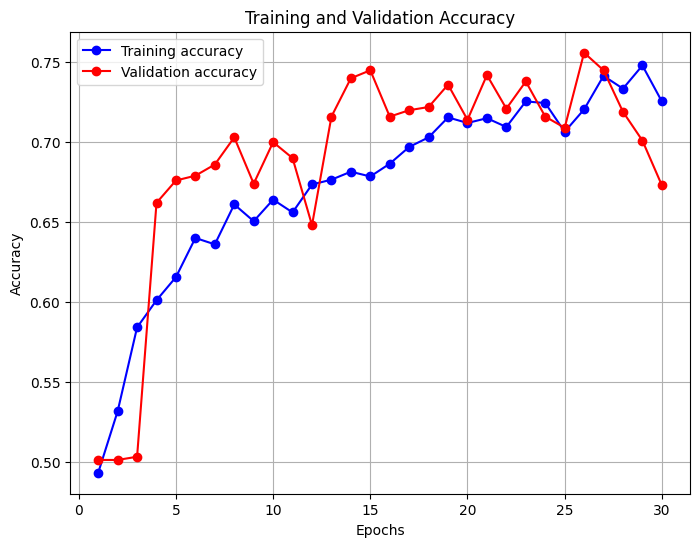

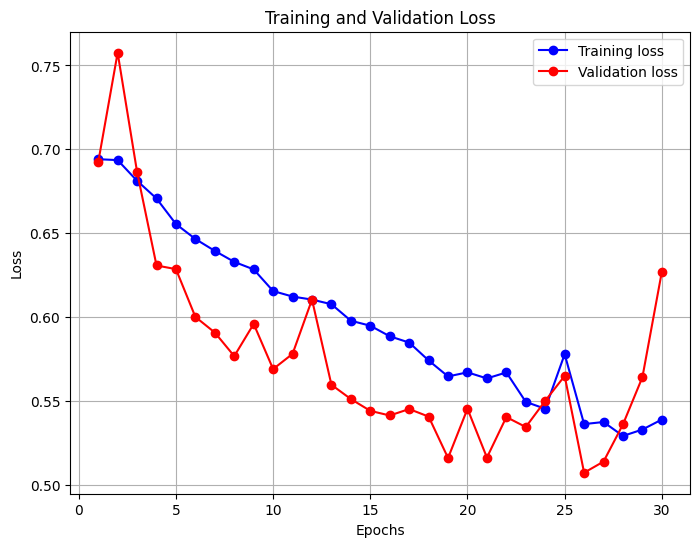

In [15]:
import matplotlib.pyplot as plt

acc = history.history["accuracy"]
val_acc = history.history["val_accuracy"]

loss = history.history["loss"]
val_loss = history.history["val_loss"]

epochs = range(1, len(val_acc) + 1)

# Plot accuracy
plt.figure(figsize=(8, 6))
plt.plot(epochs, acc, "bo-", label="Training accuracy")
plt.plot(epochs, val_acc, "ro-", label="Validation accuracy")
plt.title("Training and Validation Accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)
plt.show()

# Plot loss
plt.figure(figsize=(8, 6))
plt.plot(epochs, loss, "bo-", label="Training loss")
plt.plot(epochs, val_loss, "ro-", label="Validation loss")
plt.title("Training and Validation Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.show()

In [16]:
import tensorflow as tf

from tensorflow.keras.applications.vgg16 import VGG16
from tensorflow.keras import models
from tensorflow.keras import layers
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras import optimizers


conv_base = VGG16(weights="imagenet", include_top=False, input_shape=(150, 150, 3))
conv_base.trainable = False

model2 = models.Sequential([
   conv_base,
   layers.Flatten(),
   layers.Dense(256, activation="relu"),
   layers.Dense(1, activation="sigmoid"),
])

model2.compile(
    loss="binary_crossentropy",
    optimizer=tf.keras.optimizers.RMSprop(learning_rate=2e-5),
    metrics=["acc"]
)


58889256/58889256 [==============================] - 0s 0us/step


In [17]:
model2.summary()

Model: "sequential_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 vgg16 (Functional)          (None, 4, 4, 512)         14714688  
                                                                 
 flatten_1 (Flatten)         (None, 8192)              0         
                                                                 
 dense_2 (Dense)             (None, 256)               2097408   
                                                                 
 dense_3 (Dense)             (None, 1)                 257       
                                                                 
Total params: 16812353 (64.13 MB)
Trainable params: 2097665 (8.00 MB)
Non-trainable params: 14714688 (56.13 MB)
_________________________________________________________________


In [18]:
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=40,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode="nearest"
)
test_datagen = ImageDataGenerator(rescale=1./255)

train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=(150, 150),
    batch_size=20,
    class_mode="binary"
)

validation_generator = test_datagen.flow_from_directory(
    validation_dir,
    target_size=(150, 150),
    batch_size=20,
    class_mode="binary"
)


Found 2000 images belonging to 2 classes.
Found 1000 images belonging to 2 classes.


In [19]:
history = model2.fit(
    train_generator,
    steps_per_epoch=100,
    epochs=100,
    validation_data=validation_generator,
    validation_steps=50
)


Epoch 1/100
100/100 [==============================] - 22s 180ms/step - loss: 0.6048 - acc: 0.6760 - val_loss: 0.4510 - val_acc: 0.8230
Epoch 2/100
100/100 [==============================] - 19s 185ms/step - loss: 0.4801 - acc: 0.7780 - val_loss: 0.3737 - val_acc: 0.8380
Epoch 3/100
100/100 [==============================] - 18s 177ms/step - loss: 0.4357 - acc: 0.8080 - val_loss: 0.3394 - val_acc: 0.8550
Epoch 4/100
100/100 [==============================] - 20s 200ms/step - loss: 0.3963 - acc: 0.8215 - val_loss: 0.3187 - val_acc: 0.8580
Epoch 5/100
100/100 [==============================] - 18s 177ms/step - loss: 0.3853 - acc: 0.8245 - val_loss: 0.3063 - val_acc: 0.8640
Epoch 6/100
100/100 [==============================] - 20s 201ms/step - loss: 0.3718 - acc: 0.8365 - val_loss: 0.3250 - val_acc: 0.8620
Epoch 7/100
100/100 [==============================] - 18s 177ms/step - loss: 0.3496 - acc: 0.8525 - val_loss: 0.2852 - val_acc: 0.8840
Epoch 8/100
100/100 [===========================

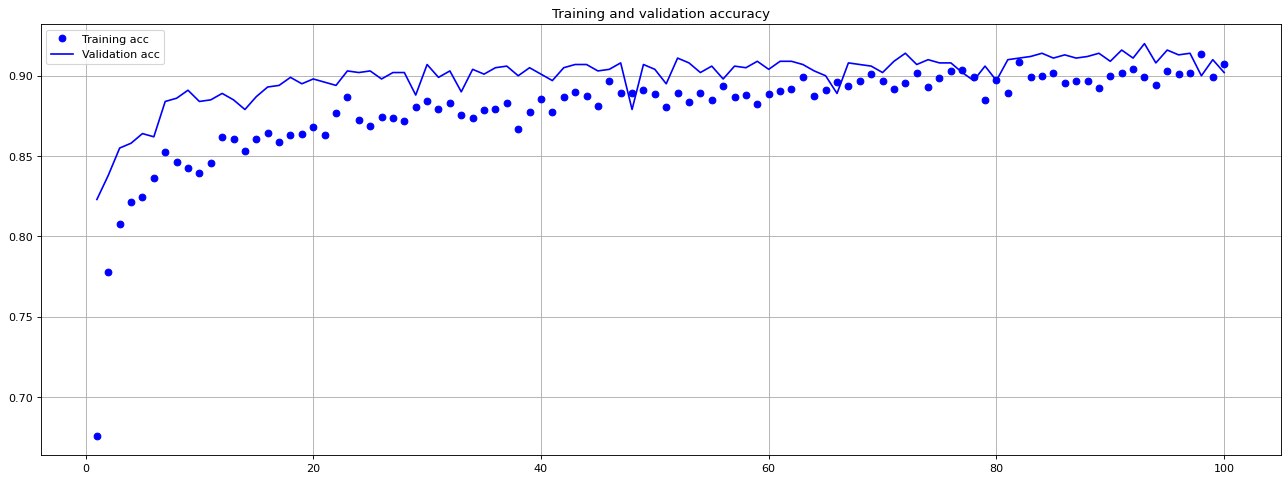

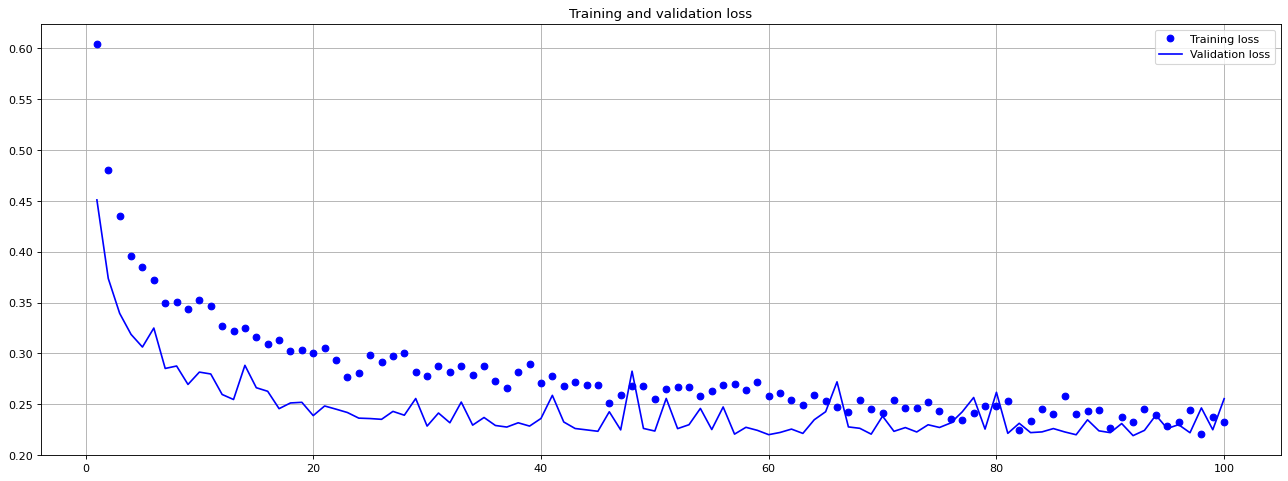

In [20]:
acc = history.history["acc"]
val_acc = history.history["val_acc"]

loss = history.history["loss"]
val_loss = history.history["val_loss"]

epochs = range(1, len(acc) + 1)

plt.figure(figsize=(20, 7), dpi=80)
plt.grid(True)

plt.plot(epochs, acc, "bo", label="Training acc")
plt.plot(epochs, val_acc, "b", label="Validation acc")

plt.title("Training and validation accuracy")
plt.legend()

plt.figure(figsize=(20, 7), dpi=80)
plt.grid(True)

plt.plot(epochs, loss, "bo", label="Training loss")
plt.plot(epochs, val_loss, "b", label="Validation loss")
plt.title("Training and validation loss")

plt.legend()
plt.show()

In [21]:
model2.save(
"/content/drive/MyDrive/prepared_train_data/models/vgg16_basesd_model.hdf5")


/usr/local/lib/python3.10/dist-packages/keras/src/engine/training.py:3103: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


In [22]:
conv_base.summary()

Model: "vgg16"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_2 (InputLayer)        [(None, 150, 150, 3)]     0         
                                                                 
 block1_conv1 (Conv2D)       (None, 150, 150, 64)      1792      
                                                                 
 block1_conv2 (Conv2D)       (None, 150, 150, 64)      36928     
                                                                 
 block1_pool (MaxPooling2D)  (None, 75, 75, 64)        0         
                                                                 
 block2_conv1 (Conv2D)       (None, 75, 75, 128)       73856     
                                                                 
 block2_conv2 (Conv2D)       (None, 75, 75, 128)       147584    
                                                                 
 block2_pool (MaxPooling2D)  (None, 37, 37, 128)       0     

In [23]:
conv_base = VGG16(weights="imagenet", include_top=False, input_shape=(150, 150, 3))

conv_base.trainable = True
set_trainable = False
for layer in conv_base.layers:
    if layer.name == "block5_conv1":
        set_trainable = True
    if set_trainable:
        layer.trainable = True
    else:
        layer.trainable = False

modified_model = models.Sequential([
   conv_base,
   layers.Flatten(),
   layers.Dense(256, activation="relu"),
   layers.Dense(1, activation="sigmoid"),
])


In [24]:
modified_model.summary()

Model: "sequential_2"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 vgg16 (Functional)          (None, 4, 4, 512)         14714688  
                                                                 
 flatten_2 (Flatten)         (None, 8192)              0         
                                                                 
 dense_4 (Dense)             (None, 256)               2097408   
                                                                 
 dense_5 (Dense)             (None, 1)                 257       
                                                                 
Total params: 16812353 (64.13 MB)
Trainable params: 9177089 (35.01 MB)
Non-trainable params: 7635264 (29.13 MB)
_________________________________________________________________


In [25]:
modified_model.compile(
    loss="binary_crossentropy",
    optimizer=tf.keras.optimizers.RMSprop(learning_rate=1e-5),
    metrics=["acc"]
)

history = modified_model.fit(
    train_generator,
    steps_per_epoch=100,
    epochs=100,
    validation_data=validation_generator,
    validation_steps=50
)

Epoch 1/100
100/100 [==============================] - 21s 182ms/step - loss: 0.5423 - acc: 0.7325 - val_loss: 0.3338 - val_acc: 0.8650
Epoch 2/100
100/100 [==============================] - 18s 178ms/step - loss: 0.3836 - acc: 0.8215 - val_loss: 0.2487 - val_acc: 0.8910
Epoch 3/100
100/100 [==============================] - 21s 215ms/step - loss: 0.3154 - acc: 0.8575 - val_loss: 0.2292 - val_acc: 0.9130
Epoch 4/100
100/100 [==============================] - 19s 185ms/step - loss: 0.2859 - acc: 0.8740 - val_loss: 0.2056 - val_acc: 0.9060
Epoch 5/100
100/100 [==============================] - 18s 181ms/step - loss: 0.2614 - acc: 0.8865 - val_loss: 0.1913 - val_acc: 0.9180
Epoch 6/100
100/100 [==============================] - 20s 204ms/step - loss: 0.2531 - acc: 0.8910 - val_loss: 0.1814 - val_acc: 0.9240
Epoch 7/100
100/100 [==============================] - 18s 179ms/step - loss: 0.2339 - acc: 0.8940 - val_loss: 0.1692 - val_acc: 0.9350
Epoch 8/100
100/100 [===========================

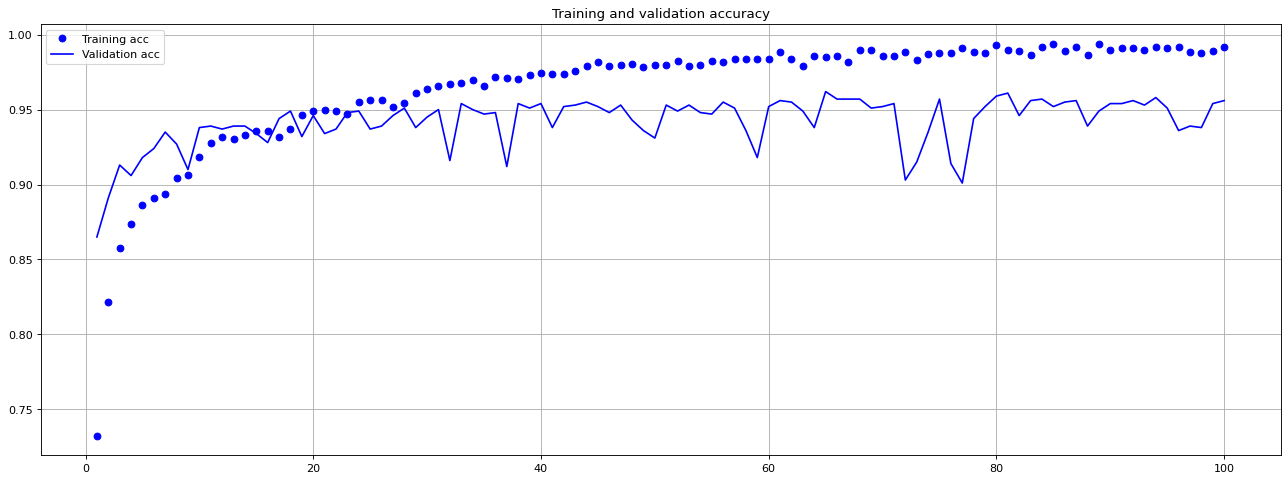

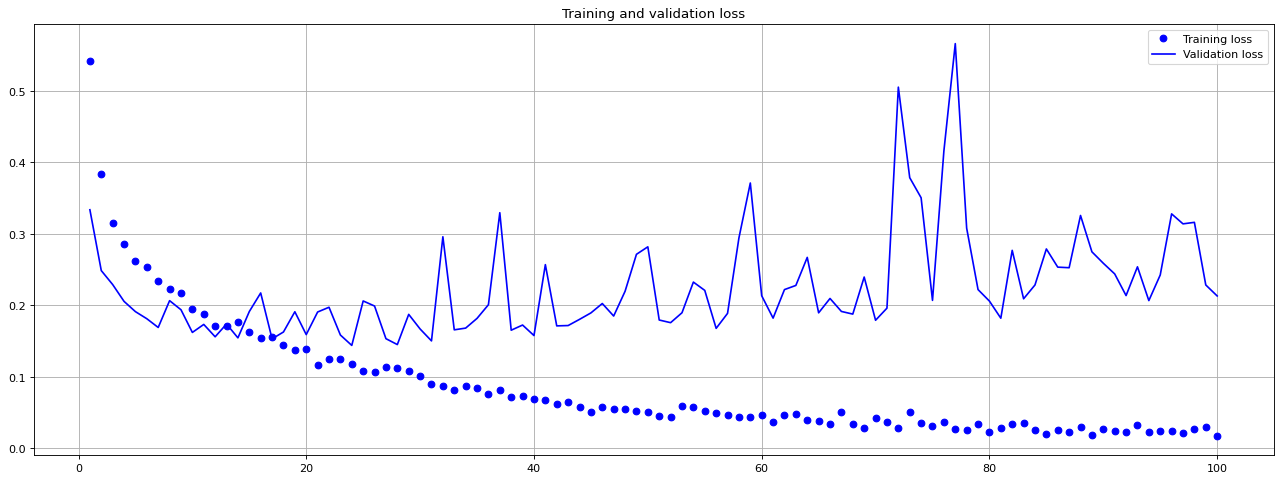

In [26]:
acc = history.history["acc"]
val_acc = history.history["val_acc"]

loss = history.history["loss"]
val_loss = history.history["val_loss"]

epochs = range(1, len(acc) + 1)

plt.figure(figsize=(20, 7), dpi=80)
plt.grid(True)

plt.plot(epochs, acc, "bo", label="Training acc")
plt.plot(epochs, val_acc, "b", label="Validation acc")

plt.title("Training and validation accuracy")
plt.legend()

plt.figure(figsize=(20, 7), dpi=80)
plt.grid(True)

plt.plot(epochs, loss, "bo", label="Training loss")
plt.plot(epochs, val_loss, "b", label="Validation loss")
plt.title("Training and validation loss")

plt.legend()
plt.show()

In [30]:
test_generator = test_datagen.flow_from_directory(
    test_dir,
    target_size=(150, 150),
    batch_size=20,
    class_mode="binary"
)

test_loss, test_acc = modified_model.evaluate_generator(test_generator, steps=50)
print("test acc:", test_acc)


Found 1000 images belonging to 2 classes.


<ipython-input-30-275b2ffa9247>:8: UserWarning: `Model.evaluate_generator` is deprecated and will be removed in a future version. Please use `Model.evaluate`, which supports generators.
  test_loss, test_acc = modified_model.evaluate_generator(test_generator, steps=50)


test acc: 0.9309999942779541


In [31]:
model2.save(
"/content/drive/MyDrive/prepared_train_data/models/vgg16_base_conv_sd_model.hdf5")

/usr/local/lib/python3.10/dist-packages/keras/src/engine/training.py:3103: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(
